<a href="https://colab.research.google.com/github/bhumikabatra13609/AIML-Project/blob/main/Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install pandas scikit-learn seaborn matplotlib

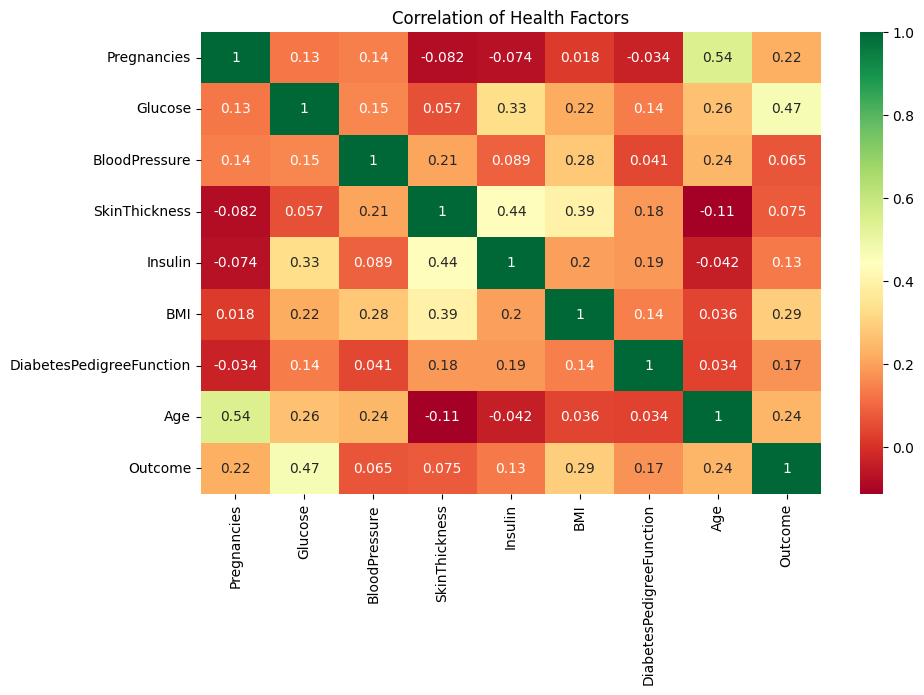

--- Model Performance ---
Accuracy Score: 0.7143

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



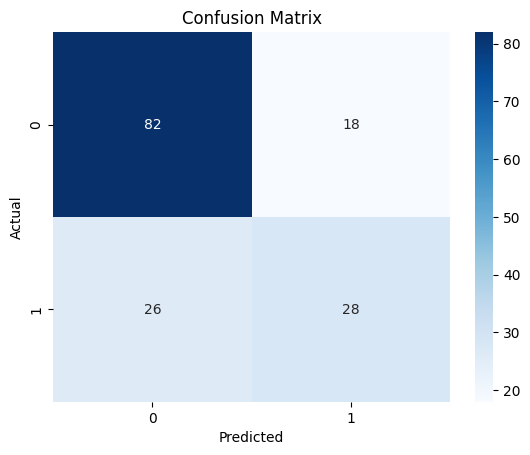


Success: Pipeline saved as diabetes_model_v1.pkl


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

data = pd.read_csv("/content/diabetes.csv")

plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(), annot=True, cmap='RdYlGn')
plt.title("Correlation of Health Factors")
plt.show()

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(C=1.0, solver='liblinear'))
])

model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

print("--- Model Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

pickle.dump(model_pipeline, open("diabetes_model_v1.pkl", "wb"))
print("\nSuccess: Pipeline saved as diabetes_model_v1.pkl")